https://github.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/blob/main/solution.ipynb

In [94]:
import numpy as np
import missingno as msno
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score,  recall_score, f1_score ,confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# **0. CONTEXTO Y CARGA DATOS**

**Objetivo**:

Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas con el objetivo de recomendar a cada individuo un determinado vino.

**Variables**: 

- fixed acidity, volatile acidity, citric acid

- residual sugar, chlorides

- free sulfur dioxide, total sulfur dioxide

- density, pH, sulphates, alcohol

In [95]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [96]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


# 1. Prepocesamiento de datos

## 1.1. Verificar valores

### 1.1.1. Unicos

In [97]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [98]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 240 filas duplicadas


In [99]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].T

,0,4,9,11,22,27,39,40,64,65,75,76,86,87,91,93,99,102,103,105,110,114,118,121,131,132,135,136,140,141,142,144,152,153,154,155,156,157,171,172,...,1435,1440,1442,1446,1450,1453,1457,1464,1465,1466,1468,1474,1476,1479,1481,1488,1491,1493,1496,1497,1499,1504,1507,1516,1517,1520,1522,1554,1557,1559,1560,1561,1562,1563,1564,1567,1579,1581,1592,1596
fixed acidity,7.4000,7.4000,7.5000,7.5000,7.9000,7.9000,7.3000,7.3000,7.2000,7.2000,8.8000,8.8000,8.6000,7.7000,8.6000,7.7000,8.1000,8.1000,8.1000,8.1000,7.8000,7.8000,8.8000,8.8000,5.6000,5.6000,8.4000,8.3000,8.4000,8.3000,5.2000,5.2000,7.500,7.500,7.1000,7.1000,7.1000,7.1000,8.0000,8.0000,...,10.20000,7.2000,6.90000,6.90000,7.2000,7.60000,7.60000,6.8000,6.8000,7.30000,7.30000,9.90000,9.90000,8.20000,8.20000,5.6000,5.6000,7.70000,7.70000,6.90000,6.90000,7.50000,7.50000,6.10000,6.50000,6.50000,6.10000,6.60000,6.60000,7.80000,7.80000,7.80000,7.20000,7.20000,7.20000,7.20000,6.20000,6.20000,6.30000,6.30000
volatile acidity,0.7000,0.7000,0.5000,0.5000,0.4300,0.4300,0.4500,0.4500,0.7250,0.7250,0.4100,0.4100,0.4900,0.4900,0.4900,0.4900,0.5450,0.5450,0.5750,0.5750,0.5600,0.5600,0.5500,0.5500,0.5000,0.5000,0.7450,0.7150,0.7450,0.7150,0.3400,0.3400,0.600,0.600,0.4300,0.4300,0.4300,0.4300,0.4200,0.4200,...,0.54000,0.3700,0.63000,0.63000,0.3700,0.49000,0.49000,0.5900,0.5900,0.48000,0.48000,0.50000,0.50000,0.28000,0.28000,0.5400,0.5400,0.54000,0.54000,0.74000,0.74000,0.38000,0.38000,0.32000,0.53000,0.53000,0.32000,0.85500,0.85500,0.60000,0.60000,0.60000,0.69500,0.69500,0.69500,0.69500,0.56000,0.56000,0.51000,0.51000
citric acid,0.0000,0.0000,0.3600,0.3600,0.2100,0.2100,0.3600,0.3600,0.0500,0.0500,0.6400,0.6400,0.2800,0.2600,0.2800,0.2600,0.1800,0.1800,0.2200,0.2200,0.1900,0.1900,0.0400,0.0400,0.0900,0.0900,0.1100,0.1500,0.1100,0.1500,0.0000,0.0000,0.030,0.030,0.4200,0.4200,0.4200,0.4200,0.1700,0.1700,...,0.37000,0.3200,0.02000,0.02000,0.3200,0.33000,0.33000,0.1000,0.1000,0.32000,0.32000,0.50000,0.50000,0.60000,0.60000,0.0400,0.0400,0.26000,0.26000,0.03000,0.03000,0.57000,0.57000,0.25000,0.06000,0.06000,0.25000,0.02000,0.02000,0.26000,0.26000,0.26000,0.13000,0.13000,0.13000,0.13000,0.09000,0.09000,0.13000,0.13000
residual sugar,1.9000,1.9000,6.1000,6.1000,1.6000,1.6000,5.9000,5.9000,4.6500,4.6500,2.2000,2.2000,1.9000,1.9000,1.9000,1.9000,1.9000,1.9000,2.1000,2.1000,1.8000,1.8000,2.2000,2.2000,2.3000,2.3000,1.9000,1.8000,1.9000,1.8000,1.8000,1.8000,1.800,1.800,5.5000,5.5000,5.5000,5.5000,2.0000,2.0000,...,15.40000,2.0000,1.90000,1.90000,2.0000,1.90000,1.90000,1.7000,1.7000,2.10000,2.10000,13.80000,13.80000,3.00000,3.00000,1.7000,1.7000,1.90000,1.90000,2.30000,2.30000,2.30000,2.30000,2.30000,2.00000,2.00000,2.30000,2.40000,2.40000,2.00000,2.00000,2.00000,2.00000,2.00000,2.00000,2.00000,1.70000,1.70000,2.30000,2.30000
chlorides,0.0760,0.0760,0.0710,0.0710,0.1060,0.1060,0.0740,0.0740,0.0860,0.0860,0.0930,0.0930,0.1100,0.0620,0.1100,0.0620,0.0800,0.0800,0.0770,0.0770,0.1040,0.1040,0.1190,0.1190,0.0490,0.0490,0.0900,0.0890,0.0900,0.0890,0.0500,0.0500,0.095,0.095,0.0700,0.0710,0.0700,0.0710,0.0730,0.0730,...,0.21400,0.0620,0.07800,0.07800,0.0620,0.07400,0.07400,0.0630,0.0630,0.06200,0.06200,0.20500,0.20500,0.10400,0.10400,0.0490,0.0490,0.08900,0.08900,0.05400,0.05400,0.10600,0.10600,0.07100,0.06300,0.06300,0.07100,0.06200,0.06200,0.08000,0.08000,0.08000,0.07600,0.07600,0.07600,0.07600,0.05300,0.05300,0.07600,0.07600
free sulfur dioxide,11.0000,11.0000,17.0000,17.0000,10.0000,10.0000,12.0000,12.0000,4.0000,4.0000,9.0000,9.0000,20.0000,9.0000,20.0000,9.0000,13.0000,13.0000,12.0000,12.0000,12.0000,12.0000,14.0000,14.0000,17.0000,17.0000,16.0000,10.0000,16.0000,10.0000,27.0000,27.0000,25.000,25.000,29.0000,28.0000,29.0000,28.0000,6.0000,6.0000,...,55.00000,15.0000,18.00000,18.00000,15.0000,27.00000,27.00000,34.0000,34.0000,31.00000,31.00000,48.00000,48.00000,10.00000,10.00000,5.0000,5.0000,23.00000,23.00000,7.00000,7.00000,5.00000,5.00000,23.00000,29.00000,29.00000,23.00000,15.00000,15.00000,31.00000,31.00000,31

In [100]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


In [101]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [102]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

Series([], dtype: float64)

[]

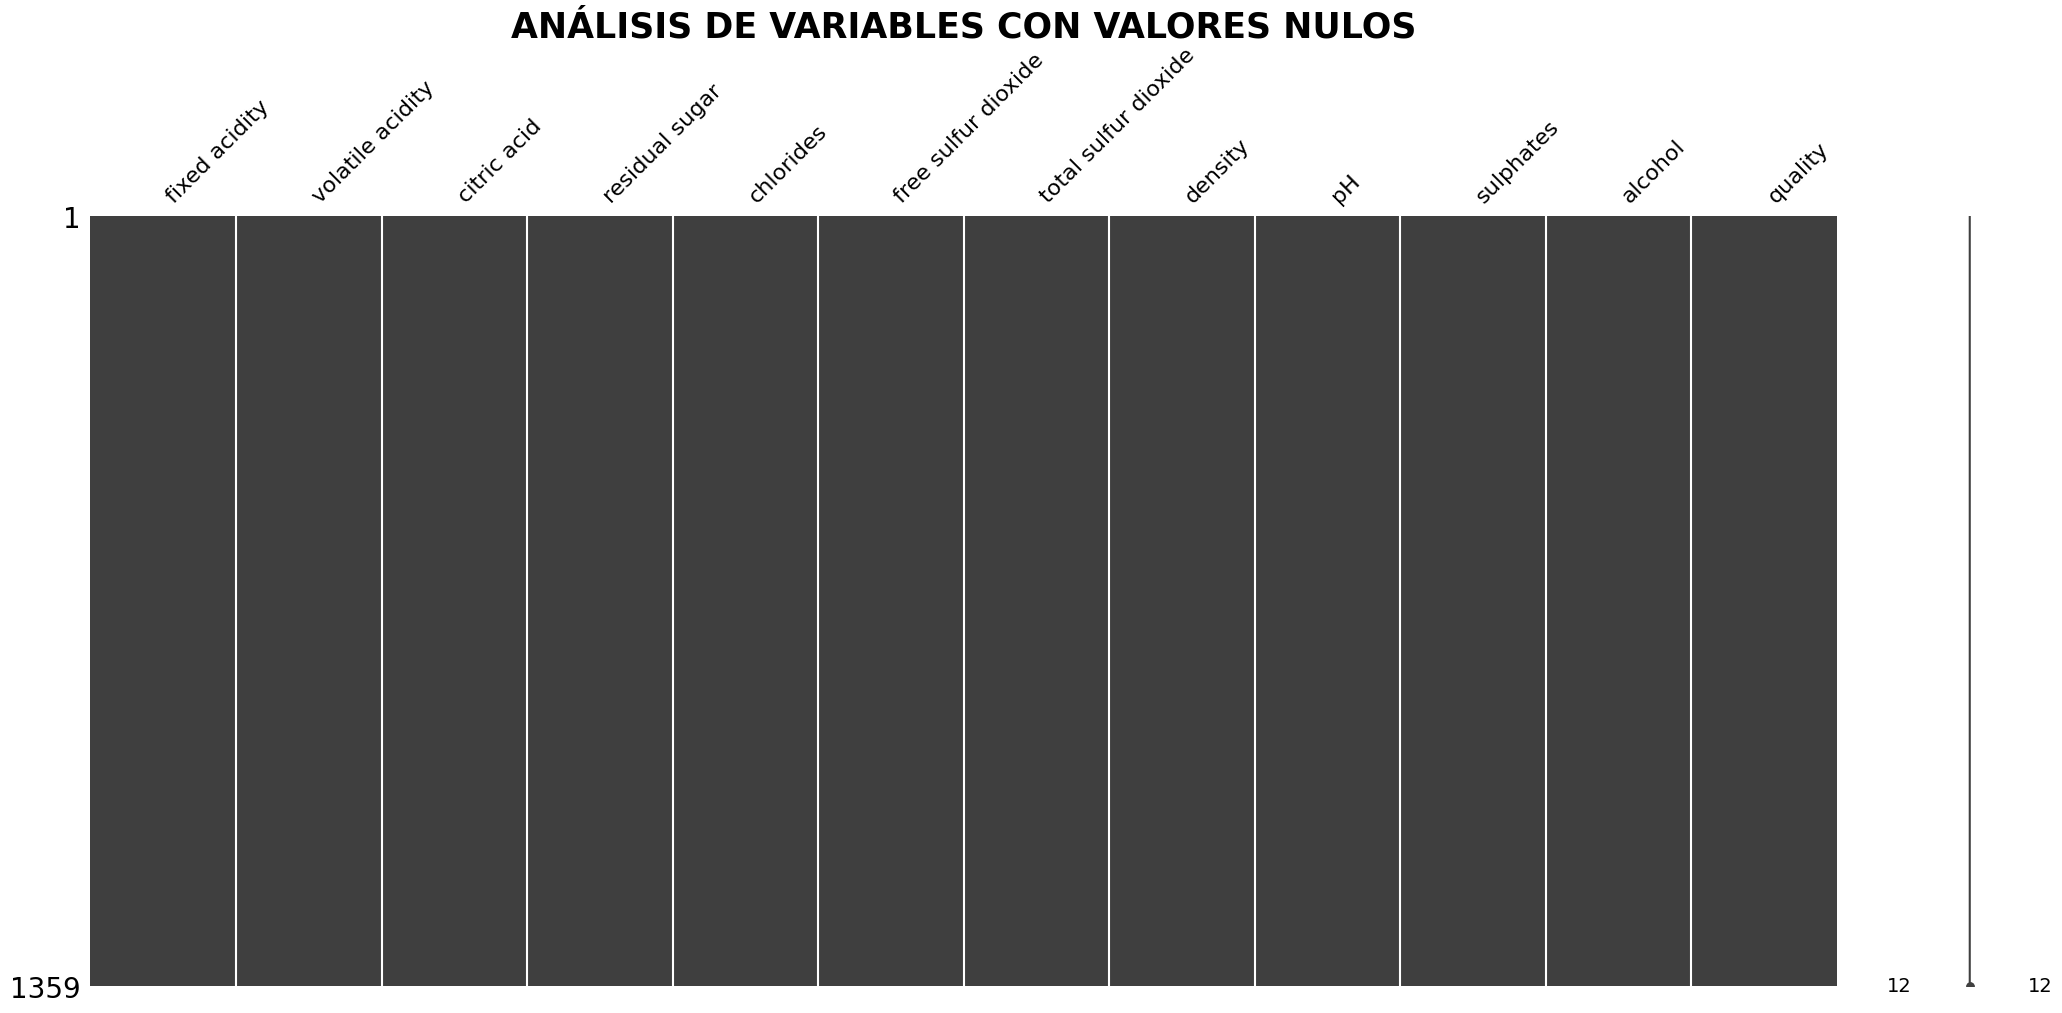

In [103]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

## 1.4. Análisis Gráfico

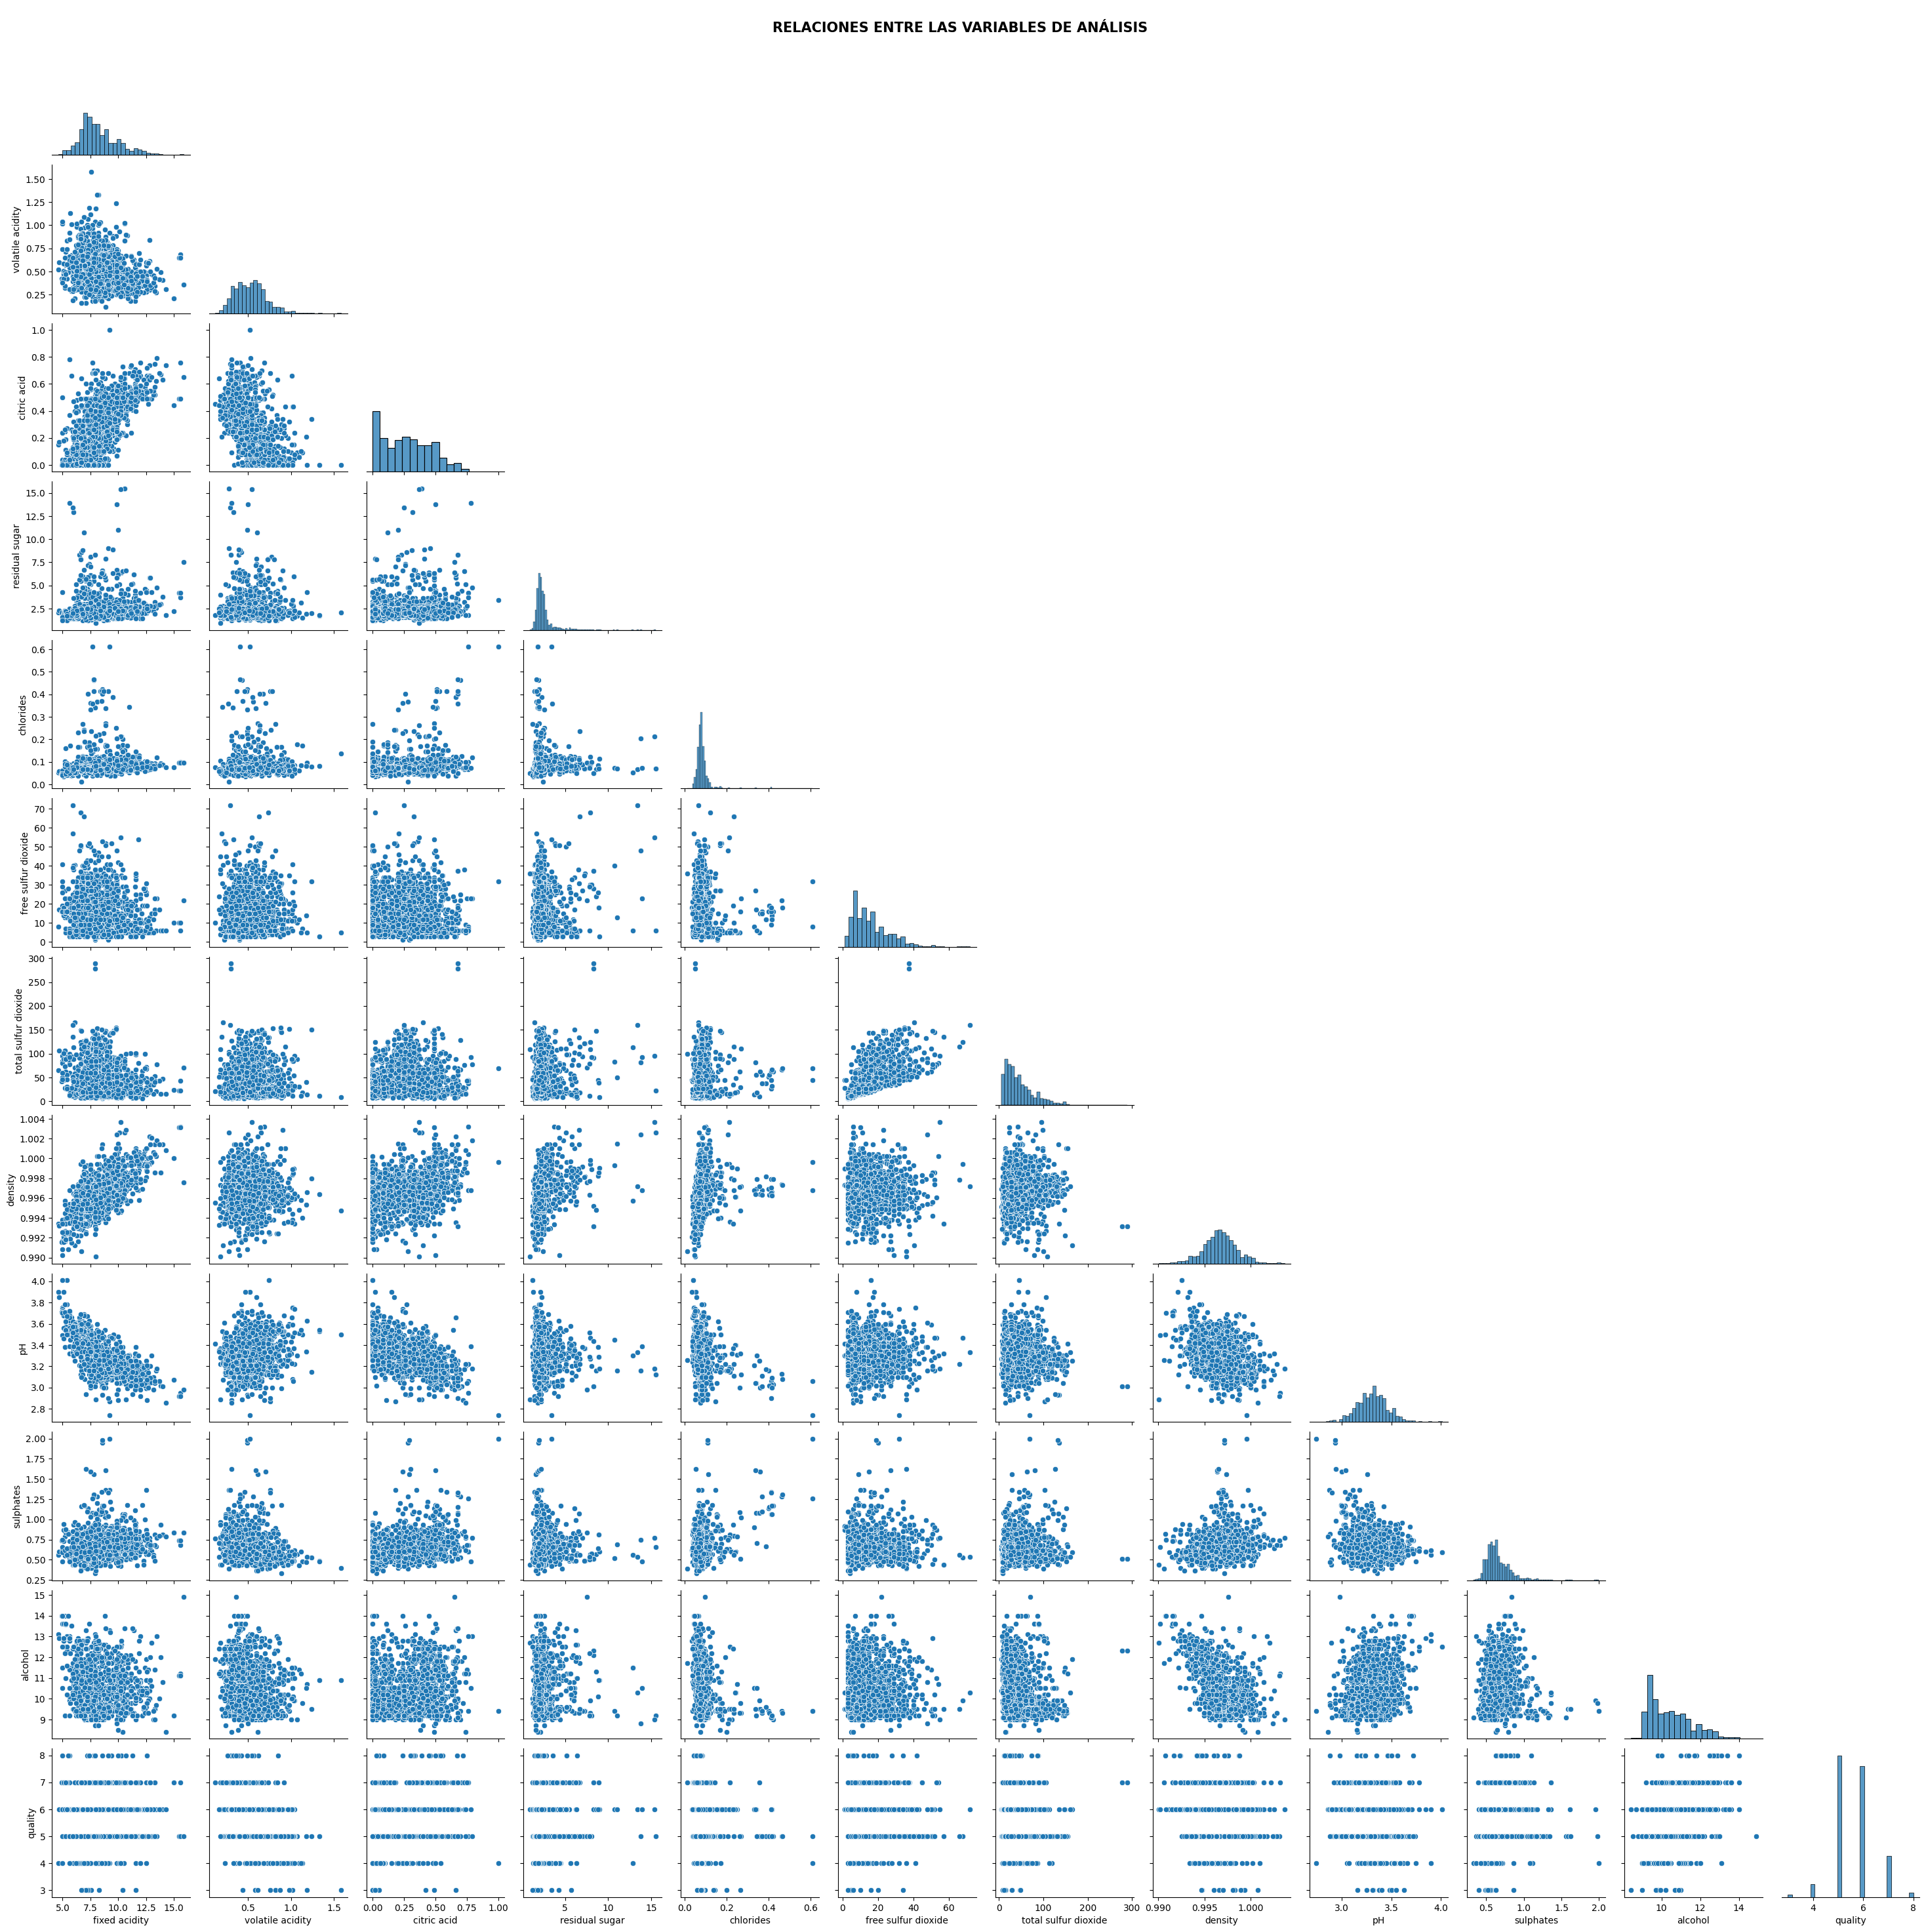

In [104]:
sns.pairplot(data=df, corner=True)
plt.suptitle("Relaciones entre las variables de análisis".upper(), fontweight="bold", size=15)
plt.show()

Se aprecia como algunas variables presentan valores extremos, lo cual será tratado con un escalado.

## 1.5. División train-test

In [105]:
#Configuración previa de quality
df["quality_cod"]=0 #Inicializamos la variable con 0
df.loc[df["quality"]<=4, "quality_cod"]=1 #Niveles de calidad 3,4y5
df.loc[(df["quality"]>4)&(df["quality"]<=6), "quality_cod"]=2 #Nivel de calidad 6
df.loc[df["quality"]>=7, "quality_cod"]=3 #Nivel de calidad 7 y 8

df["quality_cod"].value_counts().sort_index(ascending=True)

quality_cod
1      63
2    1112
3     184
Name: count, dtype: int64

In [106]:
#Diviisón de la base de datos
X = df.drop(['quality', 'quality_cod'],axis=1)
y = df['quality_cod']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) 
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1016,8.9,0.38,0.40,2.2,0.068,12.0,28.0,0.99486,3.27,0.75,12.60
1521,6.9,0.48,0.20,1.9,0.082,9.0,23.0,0.99585,3.39,0.43,9.05
452,6.8,0.56,0.03,1.7,0.084,18.0,35.0,0.99680,3.44,0.63,10.00
848,6.4,0.64,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.80
58,7.8,0.59,0.18,2.3,0.076,17.0,54.0,0.99750,3.43,0.59,10.00


## 1.6. Escalado

Dadi que las características no están en la misma escala, aquellas con magnitudes más grandes pueden dominar la distancia y afectar el resultado del algoritmo. Por lo tanto, aplicaremos un ``MinMaxScaler`` para homogeneizar las magnitudes de las variables. 

In [107]:
# Instaciamos el escalador
scal=MinMaxScaler()
# Ajustamos y transformamos para train
X_train_sc=pd.DataFrame(scal.fit_transform(X_train), columns=X_train.columns)
# Solo transformamos para test (independia base datos)
X_test_sc=pd.DataFrame(scal.transform(X_test), columns=X_test.columns)

In [108]:
X_train_sc.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,0.328541,0.278594,0.272677,0.112396,0.129042,0.198410,0.145117,0.487697,0.447493,0.197142,0.312681
std,0.154009,0.122608,0.194711,0.097421,0.086688,0.149451,0.118124,0.137237,0.120331,0.103839,0.166900
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.221239,0.184932,0.100000,0.068493,0.096828,0.071429,0.056537,0.406021,0.370079,0.131737,0.169231
50%,0.292035,0.273973,0.260000,0.089041,0.111853,0.171429,0.113074,0.488253,0.448819,0.173653,0.261538
75%,0.398230,0.356164,0.420000,0.116438,0.131886,0.271429,0.204947,0.567548,0.519685,0.239521,0.415385
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1.7. Entrenamiento modelo

In [109]:
# Instanciamos y entrenamos el modelo
model = KNeighborsClassifier(n_neighbors=5, #Vecinos más cercanos
                             weights="distance", #vecinos más cercanos tienen más peso
                             metric='minkowski', #métrica lineal
                             p=2) #euclidiana
model.fit(X_train_sc, y_train)

KNeighborsClassifier(weights='distance')

# 2. Evaluación modelo KNN

In [110]:
# Realizamos las predicciones
y_hat_train=model.predict(X_train_sc)
y_hat_test=model.predict(X_test_sc)

In [111]:
#Accuracy
print(f"Porcentaje total de clasificados correctamente: {round(accuracy_score(y_test, y_hat_test)*100,2)}%")
print("="*55)
print("Métricas de clasificación:\n", classification_report(y_test, y_hat_test))
print("="*55)
print(f"Distribución de las categorias: \n {pd.concat([y_test.value_counts(), round(y_train.value_counts(normalize=True), 4)], 
          axis=1, keys=["Observado", "Porcentaje"]).sort_index(ascending=True)}")

Porcentaje total de clasificados correctamente: 84.19%
Métricas de clasificación:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00        13
           2       0.88      0.93      0.91       226
           3       0.56      0.55      0.55        33

    accuracy                           0.84       272
   macro avg       0.48      0.49      0.49       272
weighted avg       0.80      0.84      0.82       272

Distribución de las categorias: 
              Observado  Porcentaje
quality_cod                       
1                   13      0.0460
2                  226      0.8151
3                   33      0.1389


A priori, podríamos afirmar que el modelo captura correctamente la distribución de los datos pues clasifica correctamente al 84,19% de las diferentes categorías de vinos en la base de datos de test.

Sin embargo, profundizando en las métricas de clasificación y en la distribución de las categorías de vino, podemos observar como el hecho de tener un desbalance importante entre las categorías está causando un ajuste muy pobre para los grupos minoritarios (0% y 55% de f1-score para los vinos de baja y alta calidad) y bastante alto para el grupo mayoritario (91% de f1-score para vinos de calidad media).

Todo esto se aprecia en la matriz de confusión, que mostraremos en terminos unitarios respecto a los valores observados.

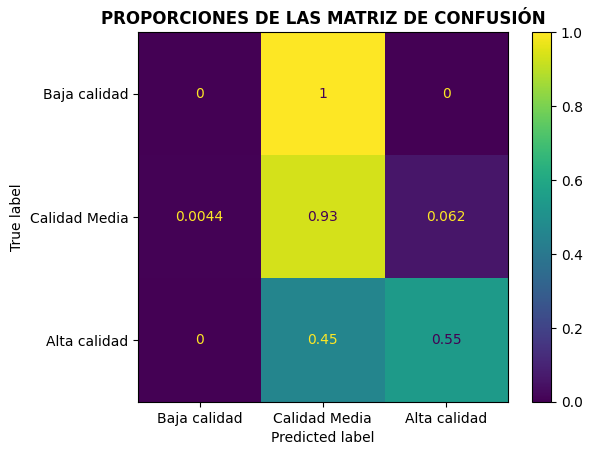

In [112]:
#Matriz de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_hat_test, normalize="true"),  display_labels=["Baja calidad", "Calidad Media", "Alta calidad"])
disp.plot()
plt.title("Proporciones de las matriz de confusión".upper(), fontweight="bold")
plt.show()

Podmeos observar como el desempeño del modelo es bastante pobre pues esta clasificando vinos de baja y alta calidad como vino de calida media. Además, solo el 55% de los vinos de calidad alta han sido predecidos correctamente. 

Esto puede estar debido al fuerte desbalance existente entre las categorías y el hecho de que porbablemente los grupos no tengas muchas diferencias entre sí. Para solucionar esto y mejorar su rendimiento, evaluaremos como evolucioan el desmepño del modelo para diferentes vecinos cercanos utilizados para clasificar. 

# 3. Optimización de hiperparámetros

In [113]:
resultado={"recall": [],"precision": [], "f1": []}

for k in range(2,25):
    # Instanciamos y entrenamos el modelo
    model = KNeighborsClassifier(n_neighbors=k, #Vecinos más cercanos
                             weights="distance", #vecinos más cercanos tienen más peso
                             metric='minkowski', #métrica lineal
                             p=2) #euclidiana
    model.fit(X_train_sc, y_train)
    #Calculamos las metricas
    resultado["f1"].append(f1_score(model.predict(X_test_sc), y_test, average='weighted')) #media ponderada de f1 por cada grupo
    resultado["precision"].append(precision_score(model.predict(X_test_sc), y_test, average='weighted'))
    resultado["recall"].append(recall_score(model.predict(X_test_sc), y_test, average='weighted'))

El número óptimo de k es 17, que arroja el valor máximo de f1 (0.906860009438027)


[]

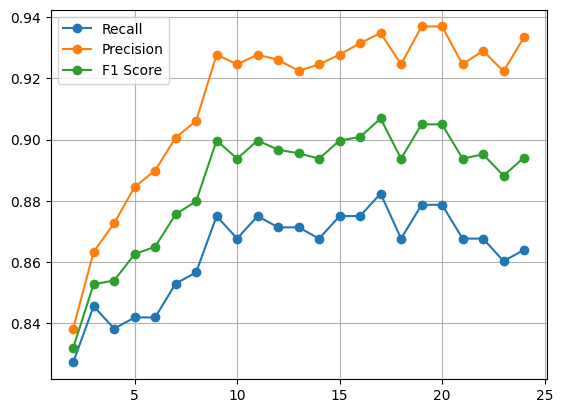

In [114]:
resultado_df=pd.DataFrame(resultado, index=range(2,25))
print(f"El número óptimo de k es {resultado_df["f1"].idxmax()}, que arroja el valor máximo de f1 ({resultado_df["f1"].max()})")
#Mostramos los resultados
plt.plot(range(2,25), resultado["recall"], marker="o", label="Recall")
plt.plot(range(2,25), resultado["precision"], marker="o", label="Precision")
plt.plot(range(2,25), resultado["f1"], marker="o", label="F1 Score")
plt.plot(17, np.max(resultado["f1"]), color="r")
plt.legend()
plt.grid(True)
plt.plot()

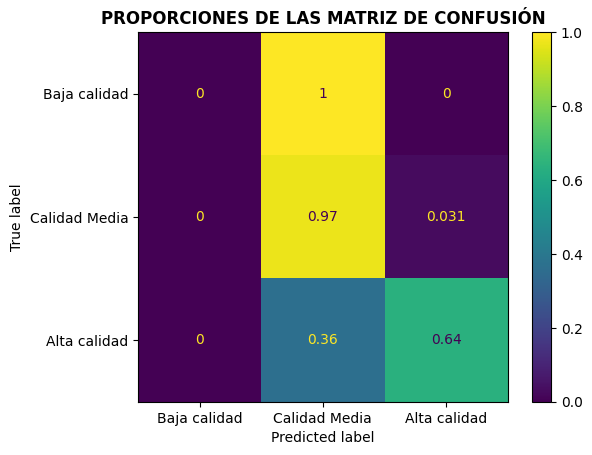

In [115]:
# Matriz de confusion
model_opt = KNeighborsClassifier(n_neighbors=17, weights="distance", metric='minkowski', p=2).fit(X_train_sc, y_train)
#Matriz de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model_opt.predict(X_test_sc), normalize="true"),  display_labels=["Baja calidad", "Calidad Media", "Alta calidad"])
disp.plot()
plt.title("Proporciones de las matriz de confusión".upper(), fontweight="bold")
plt.show()

En este caso, podemos observar como el proceso de optimización ha corregido los falsos vinos de calidad media en 9 puntos porcentuales del total de vinos de alta calidad.

# 4. Predicción

In [116]:
def cal_pred(lista):
    #Hacer el escalado
    var_scal=scal.transform(pd.DataFrame(lista).T)
    #Devolvemos las predicción
    cal_pred=model_opt.predict(var_scal)

    if cal_pred==1:
        return "El vino probablemente sea de baja calidad 🍷"
    elif cal_pred==2:
        return "El vino probablemente sea de calidad media 🍷"
    else: 
        return "El vino probablemente sea de calidad alta 🍷"

In [117]:
cal_pred([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

'El vino probablemente sea de calidad media 🍷'